In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

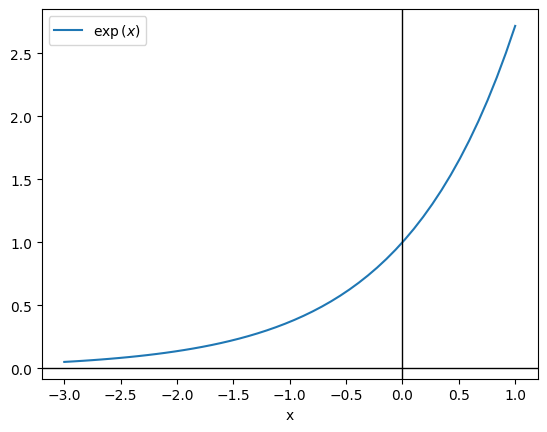

In [2]:
# Normal exp function
x = np.linspace(-3, 1)
plt.plot(x, np.exp(x), label=r'$\exp{(x)}$')
plt.axvline(color='k', linewidth=1)
plt.axhline(color='k', linewidth=1)
plt.xlabel('x')
plt.legend()
plt.show()

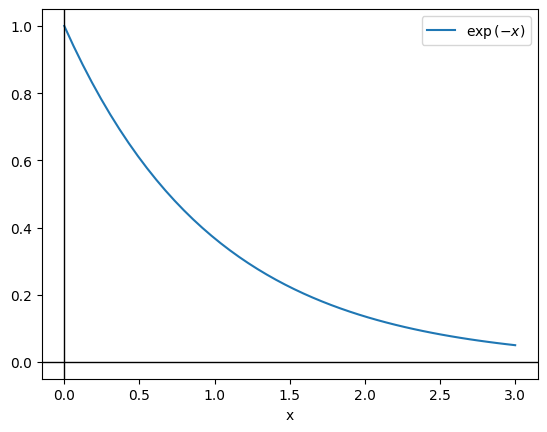

In [3]:
# Normal exp function
x = np.linspace(0, 3)
plt.plot(x, np.exp(-x), label=r'$\exp{(-x)}$')
plt.axvline(color='k', linewidth=1)
plt.axhline(color='k', linewidth=1)
plt.xlabel('x')
plt.legend()
plt.show()

#### Exponential Time Decay

$$w(\Delta t) = \exp{(-\lambda \Delta t)}$$

Where:
- $\lambda$: decay rate, $0 < \lambda < 1$
- $\Delta t$: time difference

Properties:
- Smooth decrease
- Memoryless
- $w(0) = 1$

Resources:
- https://en.wikipedia.org/wiki/Exponential_decay
- https://gregorygundersen.com/blog/2022/05/17/exponential-decay/

In [4]:
def exponential_decay(t, decay_rate: float = 0.01) -> np.array:
    return np.exp(-decay_rate*t)

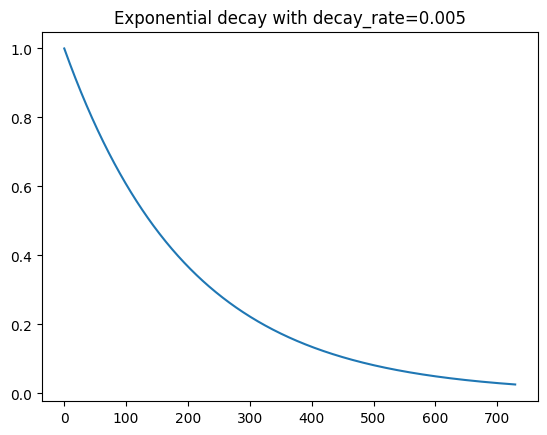

In [5]:
year = 2
t = np.arange(year * 365)
decay_rate = 0.005
plt.plot(t, exponential_decay(t, decay_rate=decay_rate))
plt.title(f'Exponential decay with {decay_rate=}')
plt.show()

Logarithmic Decay

In [6]:
def logarithmic_decay(t):
    return 1 / np.log(2 + t)

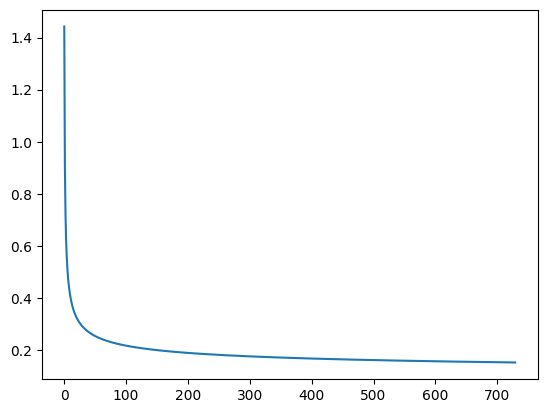

In [7]:
year = 2
x = np.arange(year * 365)
plt.plot(x, logarithmic_decay(x))

-> Not suitable for movie recommendations

---
Half-life ($t_{1/2}$): the time required for the decaying quantity to fall to one half of its initial value

To find decay rate to reduce weight by half (half-life):

$w(\Delta t) = \exp{(-\lambda \Delta t)}$

$\Leftrightarrow 0.5 = \exp{(-\lambda \Delta t)} = \dfrac{1}{\exp{(\lambda \Delta t)}}$

$\Leftrightarrow \exp{(\lambda \Delta t)} = 2$

$\Leftrightarrow \lambda \Delta t = \ln{2}$

$\Leftrightarrow \lambda = \dfrac{\ln{2}}{\Delta t}$

So, for example, if we want to reduce weight by half after 180 days (~half a year), we should set the decay rate to be: $\lambda = \dfrac{\ln{2}}{180} \approx 0.00385$

In [8]:
np.log(2) / 180

np.float64(0.003850817669777474)

In [9]:
def half_life(t) -> float:
    return float(np.log(2) / t)

half_life(180)

0.003850817669777474

In [10]:
def plot_exponential_decay(t, decay_rate: float = 0.005) -> None:
    plt.plot(t, exponential_decay(t, decay_rate=decay_rate), label=f'exp(-{decay_rate}t)')
    plt.title(f'Exponential decay with {decay_rate=}')
    # plt.show()

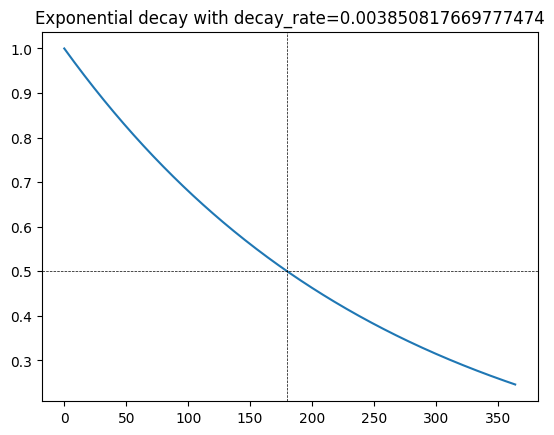

In [11]:
year = 1
days = year * 365
t = np.arange(days)
plot_exponential_decay(t, decay_rate=half_life(180))
plt.axvline(180, color='k', linestyle='--', linewidth=0.5)
plt.axhline(1/2, color='k', linestyle='--', linewidth=0.5)
plt.show()

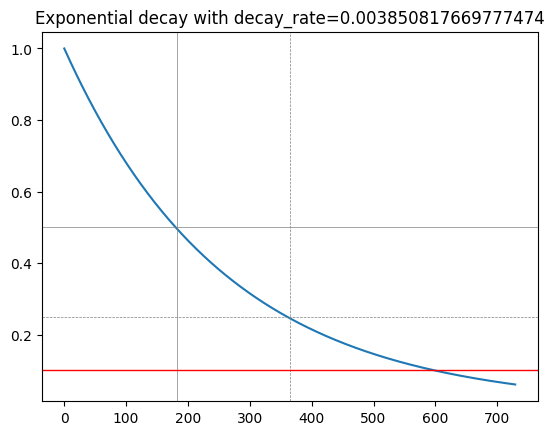

In [12]:
plot_exponential_decay(np.arange(2*365), decay_rate=half_life(180))

plt.axvline(days/2, color='gray', linestyle='-', linewidth=0.5)
plt.axhline(1/2, color='gray', linestyle='-', linewidth=0.5)

plt.axvline(days, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(1/4, color='gray', linestyle='--', linewidth=0.5)

plt.axhline(0.1, color='r', linewidth=1, linestyle='-')

Reduce weight by half after a year: $\lambda = \dfrac{\ln{2}}{365}$

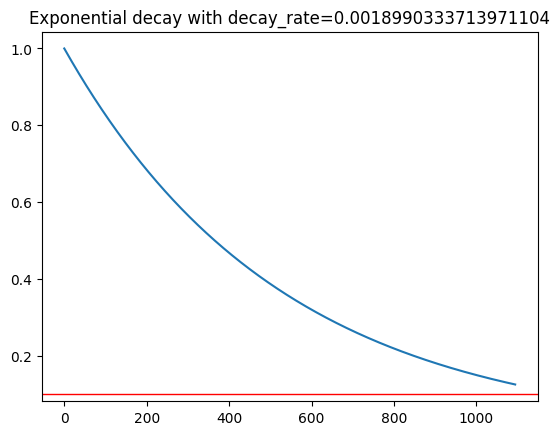

In [13]:
plot_exponential_decay(np.arange(3*365), decay_rate=half_life(365))
plt.axhline(0.1, color='r', linewidth=1, linestyle='-')

#### Playground

Text(0.5, 1.0, 'Exponential decays in 3 years')

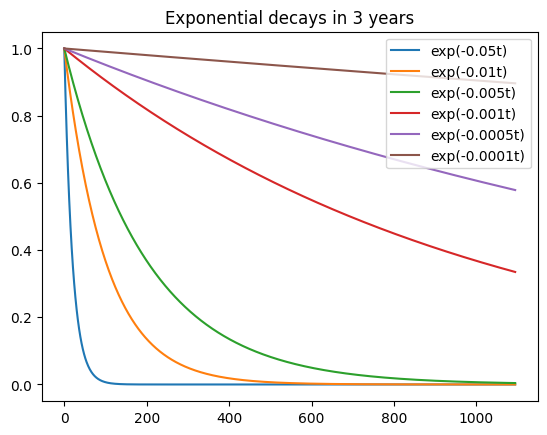

In [14]:
decay_rates = [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
year = 3
days = year * 365
t = np.arange(days)
for rate in decay_rates:
    plot_exponential_decay(t, decay_rate=rate)

plt.legend(loc='upper right')
plt.title(f'Exponential decays in {year} years')

-> Decay rate sutable range is from 0.01 to 0.005

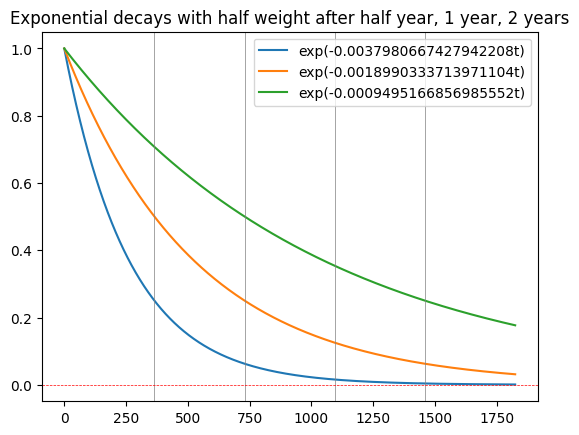

In [17]:
t = np.arange(5 * 365)
for year in [1/2, 1, 2]:
    days = year * 365
    decay_rate = half_life(days)
    plot_exponential_decay(t, decay_rate=decay_rate)

plt.legend(loc='upper right')
plt.title(f'Exponential decays with half weight after half year, 1 year, 2 years')

plt.axvline(365, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(365*2, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(365*3, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(365*4, color='gray', linestyle='-', linewidth=0.5)

plt.axhline(0, color='r', linestyle='--', linewidth=0.5)

-> suitable half life: 180 days (half year)

#### Playground

In [59]:
import pandas as pd

df = pd.read_csv('../data/data.csv')
df = df[df['status'] == 'completed']
df = df.drop(columns='note')
df.tail()

,name,year,status,type,country,genres,rating,watched_date
284,Hi-Five,2025,completed,movie,Korea,"comedy,action,sci-fi,fantasy",8.0,2025-11-14
299,Rango,2011,completed,movie,US,"comedy,animation,adventure",8.0,2025-11-24
313,Marty Supreme,2025,completed,movie,US,"sport,drama",9.0,2026-02-27
339,Ne Zha (Na Tra),2019,completed,movie,China,"animation,family,adventure,fantasy",9.0,2026-01-25
350,The Daily Life of the Immortal King 5,2025,completed,series,China,"comedy,animation,action,adventure",7.0,2026-02-22


In [62]:
def normalize_watched_date(date_str):
    if pd.isna(date_str):
        return None
    
    date_str = str(date_str)

    # conver to mid year for year-only and year with month data, mid year is 1 July
    if len(date_str) == 4:  # YYYY
        return pd.Timestamp(f'{date_str}-07-01')

    if len(date_str) == 7:  # YYYY-MM
        return pd.Timestamp(f'{date_str}-15')

    return pd.Timestamp(date_str)

df['watched_date'] = df['watched_date'].apply(normalize_watched_date)

In [63]:
today = pd.Timestamp.today().normalize()  # .normalize() removes the time portion
today

Timestamp('2026-03-07 00:00:00')

In [64]:
days_since_watch = (today - df['watched_date']).dt.days
days_since_watch.tail()

284    113
299    103
313      8
339     41
350     13
Name: watched_date, dtype: int64

In [65]:
(df['watched_date'].loc[339] - today).days

-41

In [66]:
today - df['watched_date'].tail()

284   113 days
299   103 days
313     8 days
339    41 days
350    13 days
Name: watched_date, dtype: timedelta64[ns]

In [67]:
def exponential_decay(t, decay_rate: float = 0.01) -> np.array:
    return np.exp(-decay_rate*t)

time_decay_weights = exponential_decay(days_since_watch, decay_rate=half_life(180))